---
# Commande pour le rendu : quarto render main.ipynb --execute
# Instructions pour quarto
title: "Traitement des données IDFM"
format:
  html:
    code-fold: true
    embed-resources: true
---

# Introduction

- **Contexte :** nous exploitons le flux GTFS d'Île‑de‑France Mobilités (IDFM) pour calculer la fréquence de passage par arrêt sur une journée de semaine représentative.
- **Objectif :** pour chaque arrêt commercial (regroupement des quais/arrêts physiques), calculer le nombre de passages par jour et par type de transport afin d'étudier des corrélations avec le marché du logement.
- **Données :** nous récuperons depuis l'API IDFM l'offre de transort sur les 30 prochains jours. Elle est dans un format standard (GTFS). Le format des données est documenté [ici](https://eu.ftp.opendatasoft.com/stif/GTFS/opendata_gtfs.pdf).
    - nettoyage 
    - regroupement des quais en arrêts commerciaux 
    - sélection d'un jour de semaine représentatif 
    - agrégation par arrêt et par type de transport 
    - export GeoJSON pour visualisation.

# Scrapping

On recupère un fichier zip depuis l'API IDFM, et on ouvre avec pandas les tables pertinentes 

:::{.callout-note}
L'API fournit les horaires des transports pour les 30 prochains jours uniquement. Les résultats affichés sur ce site utilisent les trajets planifiés le **12 janvier 2026**, à partir de données téléchargées le 25 décembre 2025. Il s'adapte automatiquement si les données utilisées sont ultérieures, mais pour assurer la reproductibilité, une version des données utilisées et mise à disposition (voir le README pour plus de détails).
:::

In [1]:
# Téléchargement et ouverture des données GTFS IDFM

DATE_REF = "20260112" # Date de référence pour le filtrage des trajets (format AAAAMMJJ) ou None pour fixer une date automatiquement

# verifie que l'exectution se fait depuis le bon répertoire
import os
if os.getcwd().endswith("notebooks"):
    os.chdir('..')

from script.download_data import get_IDFM_data_path
import pandas as pd

# voir le fichier script/download_data.py pour le détail de la fonction
file_names = get_IDFM_data_path(force_download=False)

# ouvrir les fichiers GTFS utiles dans des DataFrames pandas
usefull_keys = ["routes", "trips", "stop_times", "stops", "calendar"]
dtype_maps = {
    "routes": {
        "route_id": str,
        "agency_id": str,
        "route_short_name": str,
        "route_long_name": str,
        "route_type": int,
    },
    "trips": {
        "route_id": str,
        "service_id": str,
        "trip_id": str,
        "trip_headsign": str,
        "direction_id": str,
        "block_id": str,
        "shape_id": str,
    },
    "stop_times": {
        "trip_id": str,
        "arrival_time": str,
        "departure_time": str,
        "stop_id": str,
        "stop_sequence": int,
        "pickup_type": str,
        "drop_off_type": str,
    },
    "stops": {
        "stop_id": str,
        "stop_code": str,
        "stop_name": str,
        "stop_desc": str,
        "stop_lat": float,
        "stop_lon": float,
        "zone_id": str,
        "parent_station": str,
        "location_type": str,
    },
    "calendar": {
        "service_id": str,
        "monday": int,
        "tuesday": int,
        "wednesday": int,
        "thursday": int,
        "friday": int,
        "saturday": int,
        "sunday": int,
        "start_date": int,
        "end_date": int,
    },
}
idfm = {}
for key, dtype in dtype_maps.items():
    path = file_names.get(key)
    idfm[key] = pd.read_csv(path, dtype=dtype, low_memory=False) # low_memory=False pour éviter les warnings


# Affichage des fichiers chargés
pd.DataFrame({
    "Fichiers ouverts": list(idfm.keys()),
    "Colonnes": [' '.join(idfm[k].keys()) for k in idfm.keys()]
})

Téléchargement depuis https://eu.ftp.opendatasoft.com/stif/GTFS/IDFM-gtfs.zip
Extraction des ZIP
Extraction terminée


,Fichiers ouverts,Colonnes
0,routes,route_id agency_id route_short_name route_long...
1,trips,route_id service_id trip_id trip_headsign trip...
2,stop_times,trip_id arrival_time departure_time start_pick...
3,stops,stop_id stop_code stop_name stop_desc stop_lon...
4,calendar,service_id monday tuesday wednesday thursday f...


# Traitement

## Regroupement des arrêts

- **Problème :** un même arrêt commercial (ex. une gare) est souvent subdivisé en plusieurs stop_id (quais, arrêts bus adjacents, etc.).
- **Choix :** nous regroupons ces stop_id en un seul identifiant « arrêt commercial » en utilisant parent_station. Une granularité aussi fine est utile pour des applications de géolocalisation d'un quai précis, mais pour analyser l'accessibilité des logements un arrêt commercial suffit et simplifie les visualisations.

In [2]:
# Regroupement : remplacer stop_id par parent_station pour les arrêts enfants
nb_stops_initial_stops = idfm["stops"]["stop_id"].nunique()
nb_stops_initial_stops_times = idfm["stop_times"]["stop_id"].nunique()

# Remplacer NA par leur propre stop_id pour les arrêts parents
idfm["stops"].fillna({"parent_station": idfm["stops"]["stop_id"]}, inplace=True)

# Remplacer stop_id par parent_station dans stop_times
idfm["stop_times"] = (
    idfm["stop_times"]
    .merge(idfm["stops"][["stop_id", "parent_station"]], on="stop_id", how="left")
    .drop(columns=["stop_id"])
    .rename(columns={"parent_station": "stop_id"})
)

# Conserver uniquement les arrêts parents dans stops
idfm["stops"] = idfm["stops"][idfm["stops"]["parent_station"] == idfm["stops"]["stop_id"]].reset_index(drop=True)

# Rendu résumé
pd.DataFrame({
    "étape": ["stop_id uniques avant", "stop_id uniques après"],
    "stops": [nb_stops_initial_stops, idfm["stops"]["stop_id"].nunique()],
    "stop_times": [nb_stops_initial_stops_times, idfm["stop_times"]["stop_id"].nunique()],
})

,étape,stops,stop_times
0,stop_id uniques avant,53903,35820
1,stop_id uniques après,15363,15363


## Selection des trajets d'un jour donné

Sélection d'un jour de semaine

- Pour obtenir des résultat dans une unité parlante (un nombre de passages par jour), nous selectionons les trajet d'un unique jour qu'on considèrera comme représentatif (un lundi).
- **Reproductibilité :** la date est fixée dans le notebook (next_monday_str = "20251215") pour obtenir des résultats reproductibles à chaque exécution.

In [3]:
# On ne conserve que les services ayant un jour donné pour calculer un nombre de trajet sur une journée en semaine

from datetime import datetime, timedelta

if not (int(DATE_REF) <= int(idfm["calendar"]["end_date"].max()) and int(DATE_REF) >= int(idfm["calendar"]["start_date"].min())):
    print("DATE_REF hors des bornes des données, ajustement automatique.")
    # utilisation du premier lundi present dans les données
    first_day = datetime.strptime(str(idfm["calendar"]["start_date"].min()), "%Y%m%d")
    first_monday = first_day + timedelta(days=(7 - first_day.weekday()) % 7)
    DATE_REF = first_monday.strftime("%Y%m%d")

print(f"Travail avec le jour: {datetime.strptime(DATE_REF, "%Y%m%d").date()}")

services_one_day = idfm["calendar"][
    (idfm["calendar"]["monday"] == 1)
    & (idfm["calendar"]["start_date"] <= int(DATE_REF))
    & (idfm["calendar"]["end_date"] >= int(DATE_REF))
]["service_id"]

trips_one_day = idfm["trips"].merge(services_one_day, on="service_id", how="inner")

pd.DataFrame({
    "description": ["trajets conservés", "trajets supprimés"],
    "valeur": [len(trips_one_day), len(idfm["trips"]) - len(trips_one_day)]
})

Travail avec le jour: 2026-01-12


,description,valeur
0,trajets conservés,145672
1,trajets supprimés,327391


## Nombre de passage par arrêt

On compte le nombre de passage de chaque ligne à chaque arrêt.

Pour l'exemple, les lignes passant par l'arrêt *Cité Universitaire* sont affichées. Les nombres de passages trouvés sont cohérents.

In [4]:
# Join et comptage
stop_times_one_day = idfm["stop_times"].merge(trips_one_day[["trip_id", "route_id"]], on="trip_id", how="inner")
stop_route_counts = stop_times_one_day.groupby(["stop_id", "route_id"]).size().reset_index(name="nb_stops_per_day")

# Ajouter infos des arrêts et des routes
stop_route_counts = (
    stop_route_counts
    .merge(idfm["stops"][["stop_id", "stop_name", "stop_lat", "stop_lon", "zone_id"]], on="stop_id", how="left")
    .merge(idfm["routes"][["route_id", "route_short_name", "route_type", "route_color"]], on="route_id", how="left")
)

# Exemple : afficher les lignes pour 'Cité Universitaire'
stop_route_counts[stop_route_counts["stop_name"] == "Cité Universitaire"].sort_values(by="nb_stops_per_day", ascending=False).head(10)

,stop_id,route_id,nb_stops_per_day,stop_name,stop_lat,stop_lon,zone_id,route_short_name,route_type,route_color
32766,IDFM:70623,IDFM:C01743,536,Cité Universitaire,48.820909,2.339534,NaN,B,2,5091CB
32765,IDFM:70623,IDFM:C01391,468,Cité Universitaire,48.820909,2.339534,NaN,T3a,0,FF7E2E
32763,IDFM:70623,IDFM:C01073,150,Cité Universitaire,48.820909,2.339534,NaN,21,3,82DC73
32764,IDFM:70623,IDFM:C01230,74,Cité Universitaire,48.820909,2.339534,NaN,216,3,FF1400


## Traitement des erreurs sur les lignes de bus

On affiche la distribution des nombre d'arrets par jour. Pour les trains, métros et tramway la distribution semble cohérente. Le nombre maximal de passage par jour est de 920 (atteint par la ligne 13 du métro), ce qui correspond à un passage toutes les 2'30'' environ (passages dans les 2 sens, 20h par jour).

On constate une incohérence pour les bus : on trouve des nombres de passages par jour dépassant 1300, ce qui est impossible.

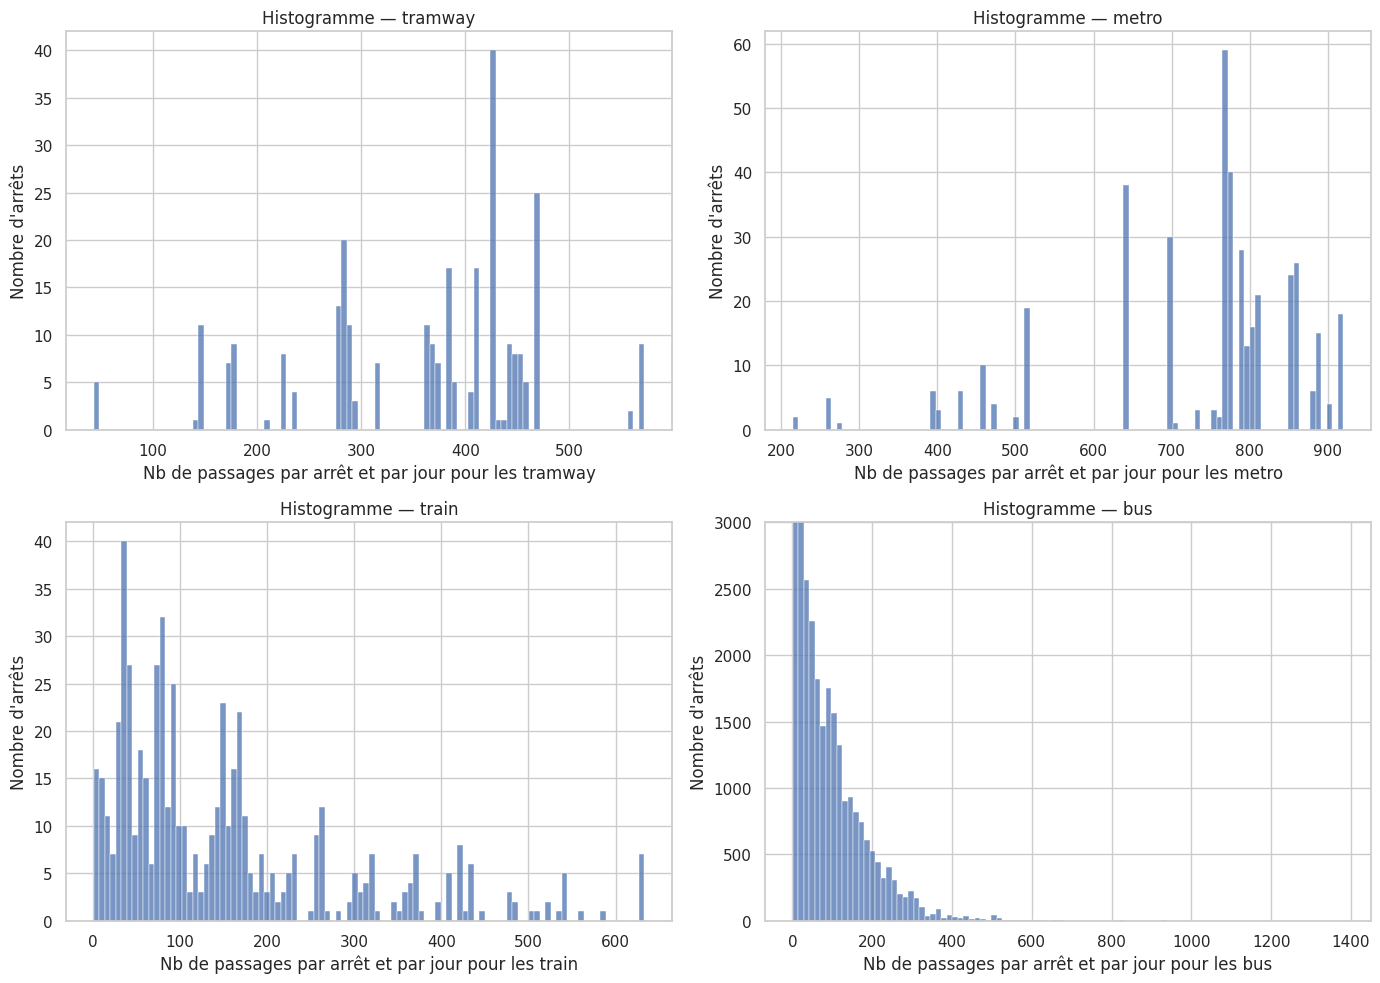

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# dictionnaire de correspondance
conversion_dict = {
    "tramway": 0,
    "metro": 1,
    "train": 2,
    "bus": 3
}

# style seaborn
sns.set_theme(style="whitegrid")

# création de la figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# boucle sur les types de transport
for ax, (target, route_type) in zip(axes, conversion_dict.items()):
    df_target = stop_route_counts[
        stop_route_counts["route_type"] == route_type
    ]

    sns.histplot(
        data=df_target,
        x="nb_stops_per_day",
        bins=100,
        ax=ax
    )

    ax.set_title(f"Histogramme — {target}")
    ax.set_xlabel(f"Nb de passages par arrêt et par jour pour les {target}")
    ax.set_ylabel("Nombre d'arrêts")

    if route_type == 3:  # bus
        ax.set_ylim(0, 3000)

# ajustement de l'espacement
plt.tight_layout()
plt.show()

Cette distribution s'explique par le regroupement de certains arrêts proches sous la forme d'un unique arrêt commercial.

On le voit par exemple pour le bus `TVM` : *La Haye aux Moines* et *Préfecture du Val-de-Marne* correspondent à un unique arret commercial, ce qui crée un arret avec 2 fois plus de passage que les autres.

In [6]:
stop_route_counts[stop_route_counts["route_short_name"] == "TVM"].sort_values(by="nb_stops_per_day", ascending=False).head(5)[["route_short_name", "stop_name", "nb_stops_per_day"]]

,route_short_name,stop_name,nb_stops_per_day
159,TVM,La Haye aux Moines / Préfecture du Val-de-Marne,1018
4940,TVM,Marcelin Berthelot,509
30964,TVM,Victor Basch,509
30948,TVM,Carrefour de la Résistance,509
5004,TVM,Pompadour,509


Pour restaurer une distribution cohérente, on remplace le nombre de passage par jour lorsque sa valeur est élevée (> 400) par la médiane observée sur la ligne.

In [7]:
df = stop_route_counts.copy()

mask = (stop_route_counts['route_type'] == 3) & (stop_route_counts['nb_stops_per_day'] > 400)

medians = stop_route_counts.groupby('route_id').agg(median_nb_stops_per_day=('nb_stops_per_day', 'median')).reset_index()

stop_route_counts = stop_route_counts.merge(medians, on='route_id', how='left')

stop_route_counts.loc[mask, "nb_stops_per_day"] = stop_route_counts.loc[mask, "median_nb_stops_per_day"].astype(int)

print(f"Pour {mask.sum()} arrêts de bus, nb_stops_per_day a été remplacé par la médiane des passages observés sur la ligne de bus.")

Pour 248 arrêts de bus, nb_stops_per_day a été remplacé par la médiane des passages observés sur la ligne de bus.


La nouvelle distribution obtenue est affichée ci-dessous. Il n'y a plus aucune valeur au dessus de 480 ce qui tend à confirmer que les valeurs élevées précédentes étaient des artefacts.

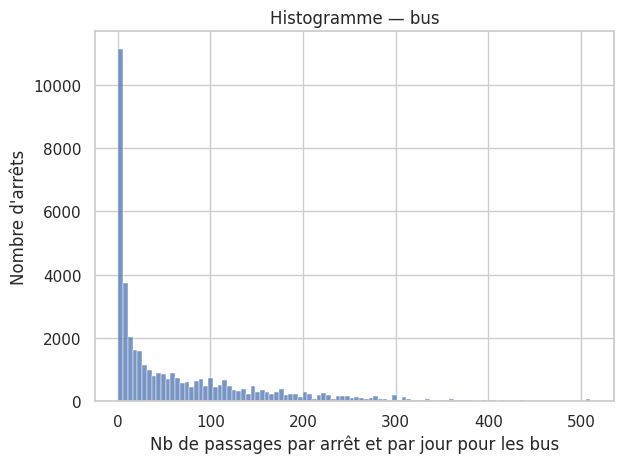

In [8]:

# boucle sur les types de transport
df_target = stop_route_counts[
    stop_route_counts["route_type"] == 3
]

ax = sns.histplot(
    data=df_target,
    x="nb_stops_per_day",
    bins=100
)

ax.set_title(f"Histogramme — {target}")
ax.set_xlabel(f"Nb de passages par arrêt et par jour pour les {target}")
ax.set_ylabel("Nombre d'arrêts")

# ajustement de l'espacement
plt.tight_layout()
plt.show()


## Regroupement par mode de transport

Nous agrégeons les passages par arrêt et par mode (`route_type`) pour obtenir, pour chaque arrêt commercial, le nombre de passages journaliers par mode.


:::{.callout-note}
Les codes GTFS 6 et 7 (funiculaire, téléphérique) sont exclus car très rares en Île‑de‑France et ont des fréquences de passage beaucoup plus éleve.
::: 


Un exemple est à nouveau donné pour l'arret *Cité Universitaire*.

In [9]:
# calcul du nombre de passage par type de transport
passage_par_arret = (
    stop_route_counts
    .groupby(["stop_id", "stop_name", "stop_lat", "stop_lon", "route_type"])["nb_stops_per_day"]
    .sum()
    .reset_index()
)

passage_par_arret = (
    passage_par_arret[passage_par_arret["route_type"].isin([0, 1, 2, 3])]
    .pivot_table(index=["stop_id", "stop_name", "stop_lat", "stop_lon"], columns="route_type", values="nb_stops_per_day", fill_value=0)
)

passage_par_arret = passage_par_arret.rename(columns={
    0: "nb_tramway_per_day",
    1: "nb_metro_per_day",
    2: "nb_train_per_day",
    3: "nb_bus_per_day"
})

passage_par_arret = passage_par_arret.reset_index()

passage_par_arret[passage_par_arret["stop_name"] == "Cité Universitaire"]

route_type,stop_id,stop_name,stop_lat,stop_lon,nb_tramway_per_day,nb_metro_per_day,nb_train_per_day,nb_bus_per_day
12056,IDFM:70623,Cité Universitaire,48.820909,2.339534,468.0,0.0,536.0,224.0


# Enregistrement

Nous obtenons deux fichier : un qui donne le nombre de passage par ligne et par arret, et un qui donne pour chaque arret une vision agrégées par mode.

Ils seront réutilisés dans dans [la partie analyse](main.html)

In [10]:
# Enregistre passage_par_arret et stop_route_counts dans un fichier GeoJSON
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path

CRS_GTFS = "EPSG:4326" # WGS84, source : https://gtfs.org/fr/documentation

# creation du dossier de sauvegarde s'il n'existe pas
dir_path = Path("cache/results")
dir_path.mkdir(parents=True, exist_ok=True)

# sauvegarde des deux geodataframes
geometry = [Point(xy) for xy in zip(passage_par_arret['stop_lon'], passage_par_arret['stop_lat'])]
gdf_synthetique = gpd.GeoDataFrame(passage_par_arret, geometry=gpd.points_from_xy(passage_par_arret["stop_lon"], passage_par_arret["stop_lat"]), crs=CRS_GTFS)
gdf_synthetique.to_file(dir_path / "passage_par_arret_synthetique.geojson", driver="GeoJSON")

geometry = [Point(xy) for xy in zip(stop_route_counts['stop_lon'], stop_route_counts['stop_lat'])]
gdf_full = gpd.GeoDataFrame(stop_route_counts, geometry=geometry, crs=CRS_GTFS)
gdf_full.to_file(dir_path / "passage_par_arret_full.geojson", driver="GeoJSON")

# Visualisation

## Affichage d'une ligne 

Une première visualisation nous permet de vérifier la cohérence du traitement effectué.

On utilise `folium` pour cartographier les arrêts desservis par les RER. Chaque cooleur represente une ligne, et un toolip permet de voir le nombre de train total passant par la station.

In [11]:
from numpy import log
import folium
from script.leaflet_tools import FondCarteLeaflet

m = FondCarteLeaflet(afficher_grande_couronne=True).get_map()

a_afficher = gdf_full[(gdf_full['route_short_name'].isin(['A', 'B', 'C', 'D', 'E'])) & (gdf_full['route_type'] == 2)][['stop_id', "route_color"]]


# filtrer les gares du RER B
gares_a_afficher = gdf_synthetique.merge(
    a_afficher,
    on='stop_id',
)

for _, row in gares_a_afficher.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=5,
        tooltip=f"{row['stop_name']}: {row['nb_train_per_day']} trains/jour",
        color=["#" + row['route_color'].lower()],
        fill=True,
        fill_color="#" + row['route_color'].lower()
    ).add_to(m)


# Sauvegarde de la carte dans assets/maps/idfm1.html
from pathlib import Path

assets = Path("assets/maps")
assets.mkdir(parents=True, exist_ok=True)

m.save(assets / "idfm1.html")

[![Interactive map](/assets/maps/idfm1.png)](/assets/maps/idfm1.html)


Les résultats sont cohérents : les arrets périphériques sont moins desservis, et les arrets croisant d'autres lignes de RER ont un nombre de passage de trains par jour bien plus élevé que les autres (Chatelet, Saint-Michel et Gare du Nord).

## Carte des zones desservies par mode

On affiche à partir de nos données les zones desservies par chaque mode de transport.

In [12]:
#| echo: false
#| warning: false
#| message: false
#| output: asis


from branca.element import Template, MacroElement, Figure

from script.leaflet_tools import FondCarteLeaflet, display_heatmap, creation_heatmap


def carte_desserte_transport(subplot, m_gdf, title, target, afficher_grande_couronne=False, display_cmap=False):
    
    m = FondCarteLeaflet(afficher_grande_couronne=afficher_grande_couronne).get_map()


    grid = creation_heatmap(m_gdf,
                            cell_size=1000,
                            target_value_col=target, 
                            min_points_per_cell=1) # pas besoin de filtrer car la distance est mesurée sans erreur

    # custom colormap
    import branca.colormap as cm


    m = display_heatmap(
        grid[grid['nb_points'] > 0],
        target_value_col="nb_points",
        cmap="no_grey",
        default_cmap_caption="Densité d'arrêts au km²",
        legend=["Nb arrêts au km²", ""],
        use_log_scale=False,
        display_cmap=display_cmap
    )

    subplot.add_child(m)

    title0 = MacroElement()
    title0._template = Template("""
    {% macro html(this, kwargs) %}
    <div style="text-align:center; font-size:16px; font-weight:600; margin:6px 0;">
    """ + title+ """
    </div>
    {% endmacro %}
    """)
    subplot.add_child(title0)

fig = Figure()

subplot = [fig.add_subplot(2, 2, i) for i in range(1, 5)]


for i, mode in enumerate(['metro', 'train', 'tramway', 'bus']):
    carte_desserte_transport(subplot[i],
                            gdf_synthetique[gdf_synthetique[f"nb_{mode}_per_day"] > 0],
                            f"Zones desservies par le {mode}",
                            f"nb_{mode}_per_day",
                            afficher_grande_couronne=(mode in ['train', 'bus']),
                            display_cmap=False)

fig.save(assets / "idfm2.html")

[![Interactive map](/assets/maps/idfm2.png)](/assets/maps/idfm2.html)

On peut conclure de cette visualisation que chaque mode de transport dessert une zone spécifique
- Métro : dessert uniquement Paris et sa proche banlieue.  
- Train (RER/TER) : desserte dense à Paris et en petite couronne, tout en couvrant également l’ensemble de la grande couronne.  
- Tramway : concentré en bordure de Paris et en petite couronne.  
- Bus : présent sur toute l’Île‑de‑France avec un réseau beaucoup plus dense que les autres modes de transport. La densité diminue lorsqu'on s'éloigne de Paris.